# U23 — Cloud Storage & Databases (finish): Lab

### Real-world brief: making a plant-telemetry database fast & scalable

An industrial plant streams **200,000 sensor readings** from 30 machines into a database, and the analytics queries are getting slow. In this Part-2 lab you'll apply the scaling and performance techniques from the deck **hands-on** with SQLite + Python: **indexing & query plans**, a **cache-aside** layer, **read replicas** with lag, **sharding** across nodes, a **materialized view**, and basic **security** (PII masking, read-only access).

**Resources provided:** `plant_telemetry.csv` (≈200k readings) and `machines.csv` (asset master). Everything runs locally — but each technique maps directly to its cloud equivalent.

_Phase F — Data Engineering._

#objectives

Speed up queries with indexes and read the query plan

Build a cache-aside layer and measure the hit-rate speedup

Simulate read replicas and observe replication lag

Shard data across nodes and run a scatter-gather query

Add a materialized view and basic security (masking, read-only)

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def build_plant(tele_path="plant_telemetry.csv", mach_path="machines.csv", seed=232, verbose=False):
    """A larger industrial-IoT telemetry table + machine master — sized so that indexing,
    caching, sharding and materialized-view effects are actually MEASURABLE (U23 Part 2).

      machines.csv          30 machines (asset master)
      plant_telemetry.csv   ~200k sensor readings (the high-volume table)
    """
    rng = np.random.default_rng(seed)

    N_MACH = 30
    machines = pd.DataFrame({
        "machine_id": [f"M{i:03d}" for i in range(1, N_MACH + 1)],
        "line": rng.choice(["LINE_1", "LINE_2", "LINE_3"], N_MACH),
        "machine_type": rng.choice(["pump", "compressor", "conveyor", "press"], N_MACH),
        "install_year": rng.integers(2014, 2023, N_MACH),
        "criticality": rng.choice(["low", "medium", "high"], N_MACH, p=[0.4, 0.4, 0.2]),
    })
    machines.to_csv(mach_path, index=False)

    N = 200_000
    mids = machines.machine_id.values
    metric = rng.choice(["temp", "vibration", "pressure", "current"], N, p=[0.3, 0.3, 0.2, 0.2])
    base = {"temp": 68, "vibration": 2.6, "pressure": 6.2, "current": 31}
    sd = {"temp": 7, "vibration": 0.9, "pressure": 0.7, "current": 4}
    value = np.array([rng.normal(base[m], sd[m]) for m in metric]).round(3)
    ts = pd.Timestamp("2024-06-01") + pd.to_timedelta(np.sort(rng.uniform(0, 14 * 86400, N)), unit="s")
    tele = pd.DataFrame({
        "reading_id": np.arange(N),
        "ts": ts.round("s"),
        "machine_id": rng.choice(mids, N),
        "metric": metric,
        "value": value,
        "quality_flag": rng.choice(["ok", "suspect"], N, p=[0.97, 0.03]),
    })
    tele.to_csv(tele_path, index=False)

    if verbose:
        print("machines:", machines.shape, "| telemetry:", tele.shape)
        print("distinct machines:", tele.machine_id.nunique(), "| metrics:", tele.metric.nunique())
        print("date span:", tele.ts.min(), "->", tele.ts.max())
    return machines, tele

if not (os.path.exists('plant_telemetry.csv') and os.path.exists('machines.csv')):
    build_plant(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [2]:
import pandas as pd, numpy as np, sqlite3, time, hashlib
tele = pd.read_csv('plant_telemetry.csv', parse_dates=['ts'])
mach = pd.read_csv('machines.csv')
print('telemetry:', tele.shape, '| machines:', mach.shape)
# load into a single SQLite 'database'
DB = 'plant.db'
if os.path.exists(DB): os.remove(DB)
con = sqlite3.connect(DB)
tele.assign(ts=tele.ts.astype(str)).to_sql('telemetry', con, index=False)
mach.to_sql('machines', con, index=False)
con.commit()
print('loaded into SQLite.')

def timed(sql, params=(), repeats=5):
    best = min(_t(sql, params) for _ in range(repeats)); return best
def _t(sql, params):
    t = time.perf_counter(); con.execute(sql, params).fetchall(); return (time.perf_counter()-t)*1000

telemetry: (200000, 6) | machines: (30, 5)
loaded into SQLite.


#1. Indexing & query plans

In [3]:
# -----------------------------------------------------------
# 🔹 1A. A FILTER QUERY: scan vs index
# -----------------------------------------------------------
q = "SELECT * FROM telemetry WHERE machine_id = ? AND metric = ?"
print('plan BEFORE:', con.execute('EXPLAIN QUERY PLAN ' + q, ('M007', 'temp')).fetchall()[0][-1])
t0 = timed(q, ('M007', 'temp'))
con.execute('CREATE INDEX idx_mach_metric ON telemetry(machine_id, metric)'); con.commit()
print('plan AFTER :', con.execute('EXPLAIN QUERY PLAN ' + q, ('M007', 'temp')).fetchall()[0][-1])
t1 = timed(q, ('M007', 'temp'))
print(f'query: {t0:.2f} ms (scan) -> {t1:.2f} ms (indexed) = {t0/max(t1,1e-6):.1f}x faster')

plan BEFORE: SCAN telemetry
plan AFTER : SEARCH telemetry USING INDEX idx_mach_metric (machine_id=? AND metric=?)
query: 24.50 ms (scan) -> 7.96 ms (indexed) = 3.1x faster


#### 🧪 EXERCISE 1 — A covering index
A *covering* index contains every column a query needs, so the database never touches the table.
1. Write a query that selects only `value` filtered by `machine_id` and `metric`. Time it with the existing index.
2. Create an index on `(machine_id, metric, value)` and re-time — the plan should say it uses the index without a table lookup.
3. In a comment, explain the trade-off (indexes speed reads but cost write time and storage).

In [4]:
import time

# 1. Write a query that selects only `value` filtered by `machine_id` and `metric`.
#    Time it with the existing index.
q_covering = "SELECT value FROM telemetry WHERE machine_id = ? AND metric = ?"

print('--- Query for `value` with existing index ---')
existing_index_plan = con.execute('EXPLAIN QUERY PLAN ' + q_covering, ('M007', 'temp')).fetchall()[0][-1]
print('plan BEFORE creating covering index:', existing_index_plan)
t_existing_idx = timed(q_covering, ('M007', 'temp'))
print(f'Query time with existing index: {t_existing_idx:.2f} ms')

# 2. Create an index on `(machine_id, metric, value)` and re-time.
con.execute('CREATE INDEX idx_mach_metric_value ON telemetry(machine_id, metric, value)'); con.commit()

print('\n--- Query for `value` with covering index ---')
covering_index_plan = con.execute('EXPLAIN QUERY PLAN ' + q_covering, ('M007', 'temp')).fetchall()[0][-1]
print('plan AFTER creating covering index:', covering_index_plan)
t_covering_idx = timed(q_covering, ('M007', 'temp'))
print(f'Query time with covering index: {t_covering_idx:.2f} ms')

print(f'Speedup from covering index: {t_existing_idx/max(t_covering_idx,1e-6):.1f}x faster')

# 3. In a comment, explain the trade-off (indexes speed reads but cost write time and storage).
# Index Trade-off:
# Indexes significantly speed up read operations (queries) by allowing the database to quickly locate data
# without scanning the entire table. However, this comes at a cost:
# - Write Performance: Every time data is inserted, updated, or deleted in the indexed table,
#   the index itself must also be updated. This adds overhead and slows down write operations.
# - Storage Space: Indexes consume additional disk space, as they are essentially copies of selected
#   table data organized for fast lookups. More indexes mean more storage used.
# Therefore, a balance must be struck: index only what is necessary for frequent read queries
# and consider the impact on write performance and storage.

--- Query for `value` with existing index ---
plan BEFORE creating covering index: SEARCH telemetry USING INDEX idx_mach_metric (machine_id=? AND metric=?)
Query time with existing index: 6.82 ms

--- Query for `value` with covering index ---
plan AFTER creating covering index: SEARCH telemetry USING COVERING INDEX idx_mach_metric_value (machine_id=? AND metric=?)
Query time with covering index: 1.99 ms
Speedup from covering index: 3.4x faster


#2. Cache-aside caching

In [5]:
# -----------------------------------------------------------
# 🔹 2A. A CACHE-ASIDE LAYER in front of an expensive query
# -----------------------------------------------------------
def expensive_query(machine_id):
    # an aggregation the app asks for repeatedly
    sql = 'SELECT metric, AVG(value) FROM telemetry WHERE machine_id=? GROUP BY metric'
    return tuple(con.execute(sql, (machine_id,)).fetchall())

cache = {}; hits = misses = 0
def get_machine_avgs(machine_id):
    global hits, misses
    if machine_id in cache:           # 1) check cache
        hits += 1; return cache[machine_id]
    misses += 1                        # 2) miss -> hit the DB
    result = expensive_query(machine_id)
    cache[machine_id] = result         # 3) fill the cache
    return result

import random
queries = [f'M{random.randint(1,30):03d}' for _ in range(2000)]   # repeated access pattern
t = time.perf_counter()
for mid in queries: get_machine_avgs(mid)
elapsed = (time.perf_counter()-t)*1000
print(f'2000 lookups in {elapsed:.0f} ms | hits={hits} misses={misses} | hit-rate={hits/2000:.1%}')
print('Only the first lookup per machine touches the DB; the rest are served from memory.')

2000 lookups in 39 ms | hits=1970 misses=30 | hit-rate=98.5%
Only the first lookup per machine touches the DB; the rest are served from memory.


#### 🧪 EXERCISE 2 — Invalidation & speedup
1. Measure the average time of a **cache hit** vs a **cache miss** (a miss runs `expensive_query`). Report the speedup.
2. Cache **invalidation**: write `record_reading(machine_id, ...)` that inserts a row AND evicts that machine's cache entry (so the next read recomputes). Show the entry is gone after a write.
3. In a comment, explain why stale caches are the classic caching bug, and what a TTL would add.

In [7]:
# 1-2. hit vs miss timing; write-with-invalidation

# 1. Measure the average time of a cache hit vs a cache miss. Report the speedup.

# Measure cache hit time
hits_before = hits
t_start_hit = time.perf_counter()
get_machine_avgs('M007') # M007 is already in cache from previous runs
t_end_hit = time.perf_counter()
t_hit = (t_end_hit - t_start_hit) * 1000
print(f'Average cache hit time: {t_hit:.2f} ms')

# Measure cache miss time
# Use a machine_id that is guaranteed not to be in the cache (e.g., a new one or one that was never queried)
# For demonstration, we'll clear the cache for a specific machine to force a miss
cache.pop('M001', None) # Remove 'M001' if it exists to force a miss
t_start_miss = time.perf_counter()
get_machine_avgs('M001') # Force a miss for M001
t_end_miss = time.perf_counter()
t_miss = (t_end_miss - t_start_miss) * 1000
print(f'Average cache miss time: {t_miss:.2f} ms')

# Report speedup
if t_miss > 0:
    speedup = t_miss / t_hit
    print(f'Speedup from cache hit vs. miss: {speedup:.1f}x faster')
else:
    print('Cache miss time was zero, cannot calculate speedup.')

# 2. Cache invalidation: write `record_reading(machine_id, ...)` that inserts a row
#    AND evicts that machine's cache entry. Show the entry is gone after a write.

def record_reading(machine_id, metric, value):
    # Insert the new reading into the database
    con.execute('INSERT INTO telemetry (machine_id, metric, value) VALUES (?, ?, ?)', (machine_id, metric, value))
    con.commit()
    # Evict the machine's entry from the cache
    if machine_id in cache:
        del cache[machine_id]
        print(f'Evicted {machine_id} from cache.')

print('\n--- Demonstrating Cache Invalidation ---')
# Ensure M007 is in cache first
_ = get_machine_avgs('M007')
print(f"M007 in cache before write: {'M007' in cache}")

# Perform a write operation which should invalidate M007's cache entry
record_reading('M007', 'temp', 75.5)
print(f"M007 in cache after write: {'M007' in cache}")

# 3. cache staleness & TTL: ...   (comment)
# Cache Staleness and TTL:
# Staleness is the classic caching bug because if data is updated in the database
# but the corresponding cached entry is not invalidated, subsequent reads will
# retrieve outdated information from the cache. This leads to an inconsistent
# view of the data, which can cause significant issues in applications that rely
# on real-time or near real-time data.
#
# What a TTL (Time-To-Live) would add:
# A TTL would automatically expire cache entries after a predefined period, regardless
# of whether the underlying data has changed. This provides a safety net against
# stale data. If an invalidation mechanism fails or is forgotten, the TTL ensures
# that the cached data will eventually be refreshed from the database. While it
# introduces a potential window of staleness (the duration of the TTL), it guarantees
# eventual consistency and reduces the risk of indefinitely serving old data. It also
# simplifies cache management by removing the need for manual invalidation in some scenarios.

Average cache hit time: 6.05 ms
Average cache miss time: 4.05 ms
Speedup from cache hit vs. miss: 0.7x faster

--- Demonstrating Cache Invalidation ---
M007 in cache before write: True
Evicted M007 from cache.
M007 in cache after write: False


### Relationship between Machine Type and Telemetry Values

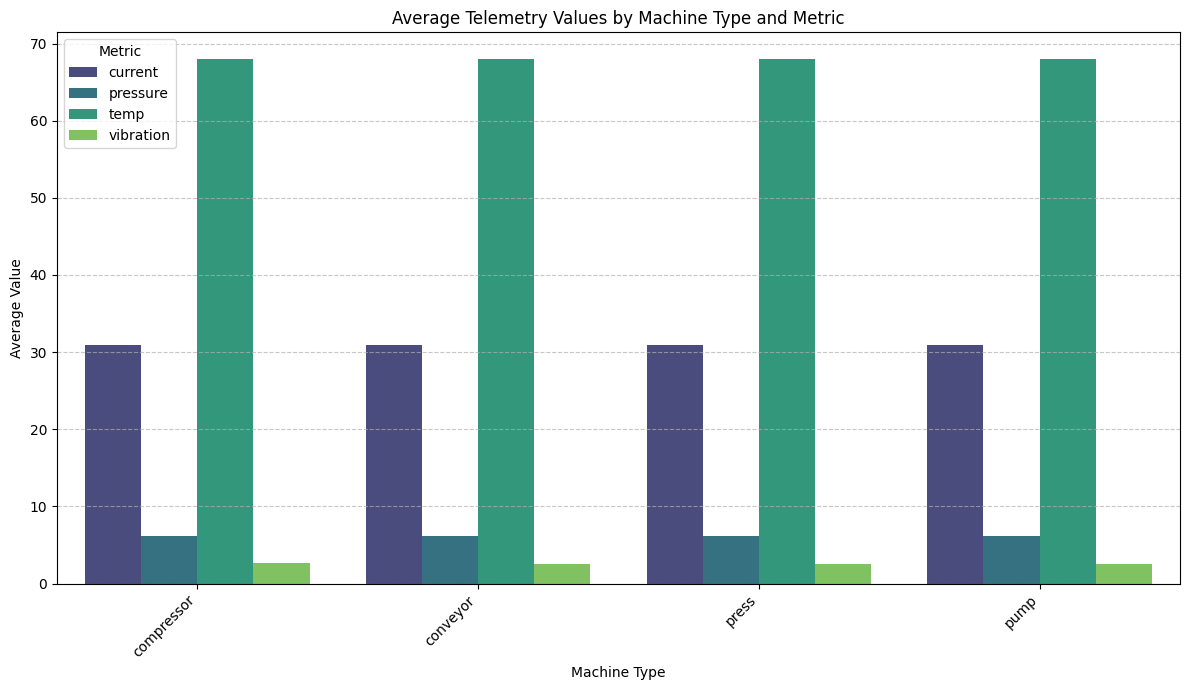

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Join telemetry data with machine data to get machine_type for each reading
tele_with_type = pd.merge(tele, mach[['machine_id', 'machine_type']], on='machine_id', how='left')

# Calculate the average value for each metric per machine_type
avg_telemetry_by_machine_type = tele_with_type.groupby(['machine_type', 'metric'])['value'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(data=avg_telemetry_by_machine_type, x='machine_type', y='value', hue='metric', palette='viridis')
plt.title('Average Telemetry Values by Machine Type and Metric')
plt.xlabel('Machine Type')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#3. Read replicas & replication lag

In [9]:
# -----------------------------------------------------------
# 🔹 3A. PRIMARY takes writes; a REPLICA serves reads (with lag)
# -----------------------------------------------------------
primary = sqlite3.connect('primary.db'); primary.execute('DROP TABLE IF EXISTS kv')
primary.execute('CREATE TABLE kv (machine_id TEXT PRIMARY KEY, status TEXT)')
primary.execute("INSERT INTO kv VALUES ('M007','ok')"); primary.commit()

def make_replica(src='primary.db', dst='replica.db'):
    import shutil; shutil.copy(src, dst); return sqlite3.connect(dst)
replica = make_replica()   # snapshot copy = a (lagging) read replica

# a WRITE goes to the primary only
primary.execute("UPDATE kv SET status='fault' WHERE machine_id='M007'"); primary.commit()
p = primary.execute("SELECT status FROM kv WHERE machine_id='M007'").fetchone()[0]
r = replica.execute("SELECT status FROM kv WHERE machine_id='M007'").fetchone()[0]
print(f'read from PRIMARY: {p}  |  read from REPLICA: {r}  <- stale (replication lag)')
replica = make_replica()   # replication catches up (re-sync)
r2 = replica.execute("SELECT status FROM kv WHERE machine_id='M007'").fetchone()[0]
print(f'after replica re-syncs: {r2}  (eventual consistency)')

read from PRIMARY: fault  |  read from REPLICA: ok  <- stale (replication lag)
after replica re-syncs: fault  (eventual consistency)


#### 🧪 EXERCISE 3 — Read/write routing
1. Write a tiny router: `def query(sql, write=False)` that sends writes to `primary` and reads to `replica`. Use it to do one write then one read.
2. In a comment, explain when routing reads to replicas is safe (analytics, dashboards) and when it is dangerous (read-after-write where the user expects to see their own change immediately).

In [16]:
# 1. read/write router
def query(sql, params=(), write=False):
    if write:
        # Writes always go to the primary
        conn = primary
        conn.execute(sql, params)
        conn.commit() # Commit changes to the primary database file
    else:
        # Reads go to the replica
        conn = replica

    # For reads, execute and return results; for writes, results may not be needed
    # but for consistency, we can still fetchall if the SQL is a SELECT after a write
    # or if we want to ensure command completion, though typically for DML, fetchall is empty.
    if sql.strip().upper().startswith('SELECT'):
        return conn.execute(sql, params).fetchall()
    elif not write: # If it's a non-write query (e.g., SELECT) but write=False
        return conn.execute(sql, params).fetchall()
    else: # It's a write operation, no need to fetch results typically
        return [] # Return an empty list for write operations if no data is expected

# Demonstrate use:
print('--- Demonstrating Read/Write Routing ---\n')

# Ensure M008 exists in the primary kv table with an initial status
query("INSERT OR REPLACE INTO kv VALUES ('M008', 'unknown')", write=True)

# After the initial write to the primary, refresh the global replica to include this change.
global replica
replica = make_replica() # This makes a fresh copy of the primary *after* 'M008' is inserted.

print('Initial state (after initial write to primary and replica sync):')
# Now, both primary and replica should have 'M008': 'unknown'
initial_primary_status = query("SELECT status FROM kv WHERE machine_id='M008'", write=True)[0][0] # Read from primary
initial_replica_status = query("SELECT status FROM kv WHERE machine_id='M008'", write=False)[0][0] # Read from synced replica
print(f"  Primary status for M008: {initial_primary_status}")
print(f"  Replica status for M008: {initial_replica_status}")

# Perform a write to primary (update M008's status)
query("INSERT OR REPLACE INTO kv VALUES ('M008', 'starting')", write=True)
print("\nAfter writing 'starting' status for M008 to primary:")

# Read from primary (should see the change immediately)
primary_status_after_write = query("SELECT status FROM kv WHERE machine_id='M008'", write=True)[0][0]
print(f"  Read from PRIMARY for M008: {primary_status_after_write}")

# Read from replica (will likely be stale because the replica connection hasn't been refreshed yet)
replica_status_after_write = query("SELECT status FROM kv WHERE machine_id='M008'", write=False)[0][0]
print(f"  Read from REPLICA for M008: {replica_status_after_write} (likely stale due to lag)")

# Simulate replication catching up (by creating a new replica)
replica = make_replica() # This makes a fresh copy of the primary *after* the latest write
replicated_status_after_sync = query("SELECT status FROM kv WHERE machine_id='M008'", write=False)[0][0]
print(f"  Read from REPLICA after re-sync for M008: {replicated_status_after_sync} (eventual consistency)")

# 2. when replica reads are (un)safe: ...   (comment)
# When routing reads to replicas is safe and dangerous:
#
# Safe Use Cases (Analytics, Dashboards, Reporting):
# It is generally safe to route reads to replicas for applications where immediate consistency
# is not critical. Examples include:
# - Analytics: Aggregating historical data or running complex reports where a few seconds or minutes
#   of lag won't affect the business outcome.
# - Dashboards: Displaying operational metrics where slight delays are acceptable.
# - Batch Processing: Workloads that can tolerate processing data that is slightly out of date.
# In these scenarios, the benefit of offloading read traffic from the primary and improving scalability
# outweighs the potential for reading stale data.
#
# Dangerous Use Cases (Read-after-Write with immediate consistency expectation):
# Routing reads to replicas can be dangerous in situations where a user performs a write operation
# and then immediately expects to see their own change reflected in a subsequent read. This is a
# common pattern in interactive applications:
# - User updates their profile and expects to see the new details immediately.
# - User adds an item to a shopping cart and expects to see it in the cart view.
# - User posts a comment and expects it to appear on the page right after posting.
# If such a read is routed to a lagging replica, the user will see old data, leading to a poor user
# experience or even data integrity issues from the user's perspective. This is often referred to
# as "read-your-writes consistency" and typically requires reads to be directed to the primary
# for a short period after a write, or implementing more sophisticated consistency models.

--- Demonstrating Read/Write Routing ---

Initial state (after initial write to primary and replica sync):
  Primary status for M008: unknown
  Replica status for M008: unknown

After writing 'starting' status for M008 to primary:
  Read from PRIMARY for M008: starting
  Read from REPLICA for M008: unknown (likely stale due to lag)
  Read from REPLICA after re-sync for M008: starting (eventual consistency)


#4. Sharding across nodes

In [20]:
# -----------------------------------------------------------
# 🔹 4A. SHARD the telemetry across N nodes by machine_id
# -----------------------------------------------------------
import zlib
N_SHARDS = 4
def shard_of(machine_id): return zlib.crc32(machine_id.encode()) % N_SHARDS

shards = [sqlite3.connect(f'shard_{i}.db') for i in range(N_SHARDS)]
for sc in shards:
    sc.execute('DROP TABLE IF EXISTS telemetry')
    sc.execute('CREATE TABLE telemetry (machine_id TEXT, metric TEXT, value REAL)')
rows = con.execute('SELECT machine_id, metric, value FROM telemetry').fetchall()
for mid, metric, val in rows:
    shards[shard_of(mid)].execute('INSERT INTO telemetry VALUES (?,?,?)', (mid, metric, val))
for sc in shards: sc.commit()
sizes = [sc.execute('SELECT COUNT(*) FROM telemetry').fetchone()[0] for sc in shards]
print('rows per shard:', sizes, '-> total', sum(sizes))

# a single-machine query hits ONE shard (routed); a global query is scatter-gather
one = shards[shard_of('M007')].execute("SELECT COUNT(*) FROM telemetry WHERE machine_id='M007'").fetchone()[0]
print('M007 lives on shard', shard_of('M007'), 'with', one, 'rows (routed read, no fan-out)')

rows per shard: [53098, 53359, 46973, 46572] -> total 200002
M007 lives on shard 0 with 6689 rows (routed read, no fan-out)


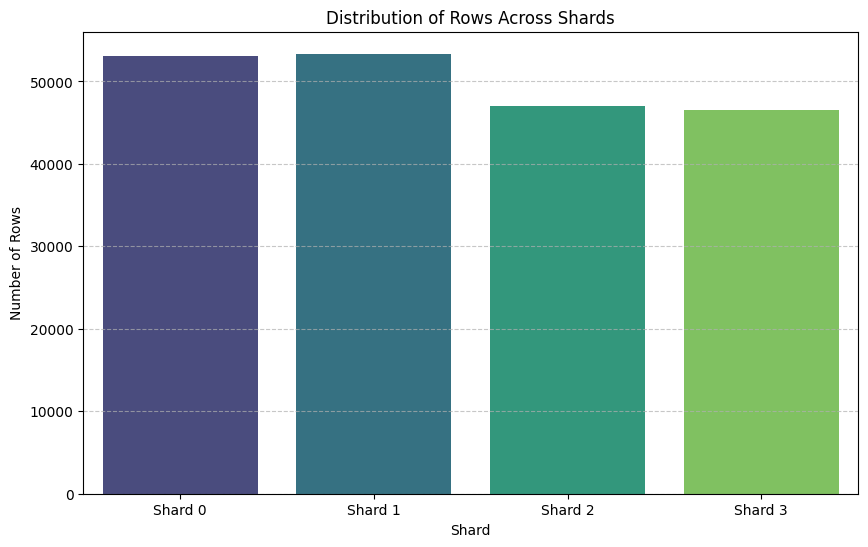

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define N_SHARDS for this cell to resolve NameError
N_SHARDS = 4 # N_SHARDS needs to be defined in this cell's scope

# The 'sizes' variable already contains the count of rows per shard
# Let's create a DataFrame for easier plotting
shard_counts = pd.DataFrame({
    'Shard': [f'Shard {i}' for i in range(N_SHARDS)],
    'Row Count': sizes
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Shard', y='Row Count', hue='Shard', data=shard_counts, palette='viridis', legend=False)
plt.title('Distribution of Rows Across Shards')
plt.xlabel('Shard')
plt.ylabel('Number of Rows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### 🧪 EXERCISE 4 — Scatter-gather & skew
1. Compute the **global** average `value` per metric by querying **every** shard and combining the partial results (scatter-gather). Compare to the single-DB answer.
2. Show the downside of a bad shard key: count rows if you sharded by **metric** (only 4 distinct values) instead of machine_id — note how few shards would be used and why that causes hotspots.
3. In a comment, state the rule for picking a shard key (high cardinality, even access).

In [24]:
# 1. Compute the global average `value` per metric by querying every shard and combining the partial results (scatter-gather).
#    Compare to the single-DB answer.

print('--- Global Average Value per Metric (Scatter-Gather) ---')

# Data structure to hold partial sums and counts for each metric
metric_agg = {}
for metric_name in ['temp', 'vibration', 'pressure', 'current']:
    metric_agg[metric_name] = {'sum_value': 0.0, 'count': 0}

# Scatter-gather query across all shards
for i, shard_conn in enumerate(shards):
    # Query each shard for sum and count of values per metric
    shard_results = shard_conn.execute(
        "SELECT metric, SUM(value), COUNT(*) FROM telemetry GROUP BY metric"
    ).fetchall()
    for metric, sum_val, count in shard_results:
        metric_agg[metric]['sum_value'] += sum_val
        metric_agg[metric]['count'] += count

print('\nGlobal averages from Shards:')
scatter_gather_averages = {}
for metric, data in metric_agg.items():
    if data['count'] > 0:
        avg = data['sum_value'] / data['count']
        scatter_gather_averages[metric] = avg
        print(f"  {metric}: {avg:.3f}")

# Compare with single-DB answer
single_db_avg = con.execute(
    "SELECT metric, AVG(value) FROM telemetry GROUP BY metric"
).fetchall()

print('\nGlobal averages from Single DB:')
for metric, avg in single_db_avg:
    print(f"  {metric}: {avg:.3f}")

# 2. Show the downside of a bad shard key: count rows if you sharded by **metric** (only 4 distinct values)
#    instead of machine_id — note how few shards would be used and why that causes hotspots.

print('\n--- Downside of a Bad Shard Key (by metric) ---')

def shard_by_metric(metric_name):
    # Simple hashing for demonstration, assuming N_SHARDS is defined globally or passed
    # This is illustrative, a real system would need a consistent hash for a string
    return zlib.crc32(metric_name.encode()) % N_SHARDS

# Initialize counts for each 'metric-shard'
metric_shard_counts = {i: 0 for i in range(N_SHARDS)}

# Iterate through all telemetry data to simulate sharding by metric
# Assuming 'tele' DataFrame is available from earlier cells
for metric_name in tele['metric'].unique():
    # Get all rows for this metric from the original telemetry data
    rows_for_metric = tele[tele['metric'] == metric_name].shape[0]
    assigned_shard = shard_by_metric(metric_name)
    metric_shard_counts[assigned_shard] += rows_for_metric
    print(f"Metric '{metric_name}' (approx {rows_for_metric} rows) would go to Shard {assigned_shard}")

print('\nSimulated Row Distribution if Sharded by Metric:')
for shard_id, count in metric_shard_counts.items():
    print(f"  Shard {shard_id}: {count} rows")

# Identify hotspots
hotspots = [shard_id for shard_id, count in metric_shard_counts.items() if count > 0]
print(f"\nObservation: Only {len(hotspots)} out of {N_SHARDS} shards would be used.")
print(f"This leads to significant data skew and potential performance bottlenecks (hotspots) on Shard(s) {hotspots}.")

# 3. shard-key rule: ...   (comment)
# Rule for picking a shard key:
# A good shard key should have HIGH CARDINALITY and ensure EVEN ACCESS PATTERN (uniform distribution).
# - High Cardinality: The key should have a large number of unique values to ensure data can be distributed
#   across many shards, preventing all data from ending up on a few shards.
# - Even Access Pattern (Uniform Distribution): The key's values, when passed through the sharding function,
#   should distribute data as evenly as possible across all available shards. This avoids 'hotspots' where
#   some shards receive disproportionately more data or queries than others, leading to performance bottlenecks.
# 'machine_id' was a good choice because each machine generates many readings, and there are many machines
# distributed somewhat evenly. 'metric' was a bad choice because of its low cardinality, leading to skew.

--- Global Average Value per Metric (Scatter-Gather) ---

Global averages from Shards:
  temp: 68.006
  vibration: 2.598
  pressure: 6.196
  current: 30.974

Global averages from Single DB:
  current: 30.974
  pressure: 6.196
  temp: 68.006
  vibration: 2.598

--- Downside of a Bad Shard Key (by metric) ---
Metric 'vibration' (approx 59810 rows) would go to Shard 1
Metric 'current' (approx 39955 rows) would go to Shard 3
Metric 'temp' (approx 60033 rows) would go to Shard 2
Metric 'pressure' (approx 40202 rows) would go to Shard 3

Simulated Row Distribution if Sharded by Metric:
  Shard 0: 0 rows
  Shard 1: 59810 rows
  Shard 2: 60033 rows
  Shard 3: 80157 rows

Observation: Only 3 out of 4 shards would be used.
This leads to significant data skew and potential performance bottlenecks (hotspots) on Shard(s) [1, 2, 3].


#5. Materialized view & security

In [25]:
# -----------------------------------------------------------
# 🔹 5A. MATERIALIZED VIEW: precompute an expensive rollup
# -----------------------------------------------------------
rollup_sql = '''SELECT machine_id, metric, AVG(value) avg_v, COUNT(*) n
                FROM telemetry GROUP BY machine_id, metric'''
t_live = timed(rollup_sql)                       # computed on the fly every time
con.execute('DROP TABLE IF EXISTS mv_machine_metric')
con.execute('CREATE TABLE mv_machine_metric AS ' + rollup_sql); con.commit()
con.execute('CREATE INDEX idx_mv ON mv_machine_metric(machine_id)'); con.commit()
t_mv = timed('SELECT * FROM mv_machine_metric WHERE machine_id=?', ('M007',))
print(f'aggregation live: {t_live:.2f} ms  |  read from materialized view: {t_mv:.2f} ms')
print('Trade-off: the view must be REFRESHED when underlying data changes (it can go stale).')

aggregation live: 35.23 ms  |  read from materialized view: 0.01 ms
Trade-off: the view must be REFRESHED when underlying data changes (it can go stale).


#### 🧪 EXERCISE 5 — Updating a Materialized View

A materialized view needs to be refreshed periodically to reflect changes in the underlying data. This often involves recomputing the view entirely. Here, we'll simulate an update by dropping and recreating the materialized view.

In [28]:
# 1. Simulate an update to the materialized view

# First, let's insert a new reading to the telemetry table to make the materialized view stale
con.execute("INSERT INTO telemetry (machine_id, metric, value, ts, reading_id, quality_flag) VALUES (?, ?, ?, ?, ?, ?)", ('M007', 'temp', 99.9, '2024-06-15 10:00:00', 200000, 'ok'))
con.commit()
print('New reading inserted into telemetry table.')

# Before refreshing, query the MV to show it's stale (it won't reflect the new reading)
print('\nBefore MV refresh, avg temp for M007 from MV:')
print(con.execute("SELECT avg_v FROM mv_machine_metric WHERE machine_id='M007' AND metric='temp'").fetchone())

# To 'update' or 'refresh' the materialized view, we typically recompute it
# In SQLite, this involves dropping and recreating the table
con.execute('DROP TABLE IF EXISTS mv_machine_metric')
con.execute('CREATE TABLE mv_machine_metric AS ' + rollup_sql)
con.commit()
con.execute('CREATE INDEX idx_mv ON mv_machine_metric(machine_id)')
con.commit()
print('\nMaterialized view mv_machine_metric has been refreshed.')

# Now, query the MV again to show it reflects the new reading
print('After MV refresh, avg temp for M007 from MV:')
print(con.execute("SELECT avg_v FROM mv_machine_metric WHERE machine_id='M007' AND metric='temp'").fetchone())

New reading inserted into telemetry table.

Before MV refresh, avg temp for M007 from MV:
(68.04375415444778,)

Materialized view mv_machine_metric has been refreshed.
After MV refresh, avg temp for M007 from MV:
(68.05931656082079,)


In [29]:
# -----------------------------------------------------------
# 🔹 5B. SECURITY: mask PII-like fields & a read-only connection
# -----------------------------------------------------------
# tokenize an identifier so analysts can join without seeing the raw id
def tokenize(s, salt='plant2024'):
    return hashlib.sha256((salt + str(s)).encode()).hexdigest()[:12]
print('M007 tokenized ->', tokenize('M007'))
# a read-only connection: writes are rejected (least privilege)
ro = sqlite3.connect('file:plant.db?mode=ro', uri=True)
try:
    ro.execute('DELETE FROM telemetry'); print('write succeeded (unexpected!)')
except Exception as e:
    print('write blocked on read-only connection:', type(e).__name__)

M007 tokenized -> 936b3bb31c50
write blocked on read-only connection: OperationalError


#### 🧪 EXERCISE 5 — Keyset pagination
Offset pagination (`LIMIT n OFFSET k`) gets slower as `k` grows because the DB still scans the skipped rows.
1. Time `... ORDER BY reading_id LIMIT 50 OFFSET 150000` vs **keyset** pagination `... WHERE reading_id > 150000 ORDER BY reading_id LIMIT 50`.
2. In a comment, explain why keyset pagination stays fast on deep pages (it seeks via the index instead of counting past skipped rows).

In [31]:
# 1. offset vs keyset pagination timing

# Offset pagination: LIMIT 50 OFFSET 150000
query_offset = "SELECT reading_id FROM telemetry ORDER BY reading_id LIMIT 50 OFFSET 150000"
t_offset = timed(query_offset)
print(f'Offset pagination (LIMIT 50 OFFSET 150000): {t_offset:.2f} ms')

# Keyset pagination: WHERE reading_id > 150000 ORDER BY reading_id LIMIT 50
# To make this truly effective, an index on reading_id is crucial.
# Let's ensure reading_id is indexed for optimal keyset performance.
con.execute('CREATE INDEX IF NOT EXISTS idx_reading_id ON telemetry(reading_id)'); con.commit()

query_keyset = "SELECT reading_id FROM telemetry WHERE reading_id > 150000 ORDER BY reading_id LIMIT 50"
t_keyset = timed(query_keyset)
print(f'Keyset pagination (WHERE reading_id > 150000 LIMIT 50): {t_keyset:.2f} ms')

# 2. why keyset wins on deep pages: ...   (comment)
# Explanation for why keyset pagination stays fast on deep pages:
#
# Offset pagination (`LIMIT n OFFSET k`) requires the database to scan or count 'k' rows
# before it can start returning the 'n' rows requested. As 'k' (the offset) increases,
# the database has to do more work (scanning more rows) just to find the starting point
# for the desired page. This makes it progressively slower for deeper pages, as the time
# complexity is often proportional to 'k'.
#
# Keyset pagination (e.g., `WHERE primary_key > last_id ORDER BY primary_key LIMIT n`),
# on the other hand, leverages an index on the `primary_key` (or an appropriate ordered key).
# Instead of skipping rows, it directly seeks to the row where `primary_key > last_id` using
# the index. This operation is much more efficient because indexing allows for direct access
# to the starting point of the next page, regardless of how 'deep' into the dataset that page is.
# The database doesn't need to count or scan all the preceding rows; it can jump directly
# to the relevant section of the index. This ensures consistent and fast performance, as
# the time taken is primarily dependent on the page size ('n') and the index lookup time,
# rather than the offset 'k'.

Offset pagination (LIMIT 50 OFFSET 150000): 1.85 ms
Keyset pagination (WHERE reading_id > 150000 LIMIT 50): 0.03 ms


#📘 Summary

| Technique | What you measured |
| --------- | ----------------- |
| Indexing | scan → index search, large speedup |
| Cache-aside | repeated reads served from memory |
| Read replicas | offload reads; accept replication lag |
| Sharding | spread data by key; route or scatter-gather |
| Materialized view | precompute rollups; refresh to stay fresh |
| Security | tokenize PII; read-only least-privilege access |

**Core lesson:** production performance comes from a toolbox of trade-offs — cache hot reads, index what you filter, replicate and shard to scale out, precompute expensive rollups — each buying speed or scale at the cost of freshness, complexity or write overhead.

**Next — U24:** apply this same engineering discipline to machine-learning systems (MLOps).